# M2 – Trägheitsmomente

**Physikalisches Grundpraktikum – HU Berlin**

Dieses Notebook wertet die Aufgaben des Versuchs M2 aus:

- **Aufgabe 2:** Lineare Regression $T^2 = f(J_Z)$ → Trägheitsmoment $J_T$ des Drehtisches
- **Aufgabe 4:** Lineare Regression $J_\gamma = f(\sin^2\gamma)$ → Überprüfung des Trägheitsellipsoids
- **Aufgabe 5:** Vergleich experimenteller und theoretischer Hauptträgheitsmomente

---

## 0. Imports

In [1]:
%run ../Imports.ipynb

---
## 1. Daten

### Zylinderparameter

In [2]:
# ── Zylinderparameter aus CSV laden ───────────────────────────────
df_zyl_info = pd.read_csv('../Data/M2/Zylinder_info.csv', index_col='Variable')
display(df_zyl_info)

# Werte extrahieren und Einheiten in SI umrechnen
m_zyl   = 1352.00 * 1e-3   # Masse des Zylinders            [kg]
u_m_zyl = 0.10   * 1e-3   # Unsicherheit der Masse         [kg]
D_zyl   = 4.41   * 1e-2   # Durchmesser des Zylinders      [m]
h_zyl   = 10.10  * 1e-2   # Höhe des Zylinders             [m]
u_d_zyl = 0.05   * 1e-2   # Unsicherheit des Durchmessers  [m]
u_h_zyl = 0.05   * 1e-2   # Unsicherheit der Höhe          [m]

R_zyl   = D_zyl / 2        # Radius                         [m]
u_R_zyl = u_d_zyl / 2      # Unsicherheit Radius            [m]                                 # Unsicherheit Radius [m]

print(f"\nZylinderparameter (SI):")
print(f"  m   = ({m_zyl*1e3:.2f} ± {u_m_zyl*1e3:.2f}) g")
print(f"  R   = ({R_zyl*1e2:.4f} ± {u_R_zyl*1e2:.4f}) cm")
print(f"  h   = ({h_zyl*1e2:.2f} ± {u_h_zyl*1e2:.2f}) cm")

,Wert
Variable,
Masse_g,1352.00
Masse_Unsicherheit_g,0.10
Durchmesser_cm,4.41
Höhe_cm,10.10
Nur_halterung_T1_s,4.90
Nur_halterung_T2_s,4.68



Zylinderparameter (SI):
  m   = (1352.00 ± 0.10) g
  R   = (2.2050 ± 0.0250) cm
  h   = (10.10 ± 0.05) cm


### Messdaten Scheibe (Aufgabe 2)

In [3]:
# Spalten: 'Index', 'S_cm', 'T1_s', 'T2_s', 'T_err_s',
#          'Anzahl_Schwingungen_n', 'Masse_scheibe_g', 'Unsicherheit_Masse_scheibe_g'
# Index-Werte: 'Tisch', 'P1' ... 'P7'
df_scheibe = pd.read_csv('../Data/M2/Daten_Scheibe.csv', index_col='Index')

print("Messdaten Scheibe:")
display(df_scheibe)

Messdaten Scheibe:


,S_cm,T1_s,T2_s,T_err_s,Anzahl_Schwingungen_n,Masse_scheibe_g,Unsicherheit_Masse_scheibe_g
Index,,,,,,,
Tisch,NaN,4.66,4.55,0.25,10,245,0.1
P1,0.00,4.96,4.98,0.25,10,245,0.1
P2,1.12,5.02,5.08,0.25,10,245,0.1
P4,2.81,5.53,5.70,0.25,10,245,0.1
P5,4.17,6.48,6.50,0.25,10,245,0.1
P6,5.66,7.51,7.32,0.25,10,245,0.1
P7,7.14,8.47,8.44,0.25,10,245,0.1


### Messdaten Zylinder (Aufgaben 4 & 5)

In [4]:
# Spalten: 'gamma_grad', 'T1_s', 'T2_s', 'Schwingungen_n'
df_zylinder = pd.read_csv('../Data/M2/Daten_Zylinder.csv')

print("Messdaten Zylinder:")
display(df_zylinder)

Messdaten Zylinder:


,gamma_grad,T1_s,T2_s,Schwingungen_n
0,NaN,4.90,4.68,10
1,0.0,5.81,5.76,10
2,15.0,6.24,6.28,10
3,30.0,6.50,6.46,10
4,45.0,7.11,7.06,10
5,60.0,7.66,7.63,10
6,75.0,8.04,8.02,10
7,90.0,8.13,8.11,10


---
## 2. Funktionen

In [5]:
# ─────────────────────────────────────────────────────────────────
#  Hilfsfunktionen
# ─────────────────────────────────────────────────────────────────

def periodendauer(t1, t2, n):
    """
    Mittlere Periodendauer T und Unsicherheit dT
    aus zwei Zeitmessungen für n Schwingungen.

    Parameters
    ----------
    t1, t2 : array-like, Zeiten für n Schwingungen [s]
    n      : array-like oder int, Anzahl Schwingungen

    Returns
    -------
    T  : np.ndarray, mittlere Periodendauer [s]
    dT : np.ndarray, Unsicherheit [s]
    """
    t1, t2, n = np.asarray(t1), np.asarray(t2), np.asarray(n)
    T  = (t1 + t2) / (2 * n)
    dT = np.abs(t1 - t2) / (2 * n)
    return T, dT


# ─────────────────────────────────────────────────────────────────
#  Aufgabe 2 – Zusatzträgheitsmoment und lineare Regression
# ─────────────────────────────────────────────────────────────────

def zusatztraegheitsmoment(m, R, s):
    """
    Zusatzträgheitsmoment der Scheibe nach Steinerschem Satz (Gl. 10):
        J_Z = (1/2)*m*R² + m*s²

    Parameters
    ----------
    m : float, Masse der Scheibe [kg]
    R : float, Radius der Scheibe [m]
    s : array-like, Abstand Scheibenachse – Drehachse [m]

    Returns
    -------
    J_Z : np.ndarray [kg·m²]
    """
    s = np.asarray(s)
    return 0.5 * m * R**2 + m * s**2


def regression_drehtisch(J_Z, T2):
    """
    Lineare Regression T² = (4π²/D)*J_Z + (4π²/D)*J_T  (Gl. 11)
    via statsmodels OLS.

    Parameters
    ----------
    J_Z : array-like, Zusatzträgheitsmomente [kg·m²]
    T2  : array-like, T² [s²]

    Returns
    -------
    model : OLS-Ergebnis
    D     : Richtmoment [N·m]
    dD    : Unsicherheit D
    J_T   : Trägheitsmoment Drehtisch [kg·m²]
    dJ_T  : Unsicherheit J_T
    """
    J_Z_const         = sm.add_constant(np.asarray(J_Z))
    model             = sm.OLS(np.asarray(T2), J_Z_const).fit()
    intercept, slope  = model.params        # b = 4π²J_T/D,  a = 4π²/D
    d_intercept, d_slope = model.bse

    D    = 4 * np.pi**2 / slope
    dD   = D * (d_slope / slope)

    J_T  = intercept / slope
    # Fehlerfortpflanzung mit Kovarianz (korrelierte Größen)
    cov  = model.cov_params()
    dJ_T = J_T * np.sqrt(
        (d_intercept / intercept)**2
        + (d_slope / slope)**2
        - 2 * cov[0, 1] / (intercept * slope)
    )
    return model, D, dD, J_T, dJ_T


def J_aus_T2(T2, D, J_T):
    """
    Trägheitsmoment aus gemessener Periodendauer T² (Gl. 9 + 11):
        J = T²·D/(4π²) − J_T

    Parameters
    ----------
    T2  : array-like, T² [s²]
    D   : float, Richtmoment [N·m]
    J_T : float, Trägheitsmoment Drehtisch [kg·m²]

    Returns
    -------
    J : np.ndarray [kg·m²]
    """
    return np.asarray(T2) * D / (4 * np.pi**2) - J_T


# ─────────────────────────────────────────────────────────────────
#  Aufgabe 4 – Trägheitsellipsoid: J_gamma = f(sin²γ)
# ─────────────────────────────────────────────────────────────────

def regression_ellipsoid(sin2_gamma, J_gamma):
    """
    Lineare Regression nach Gl. (12):
        J_γ = J_z + (J_y − J_z)·sin²γ
    Achsenabschnitt = J_z,  Anstieg = J_y − J_z

    Parameters
    ----------
    sin2_gamma : array-like, sin²(γ)
    J_gamma    : array-like, Trägheitsmomente [kg·m²]

    Returns
    -------
    model : OLS-Ergebnis
    J_z   : Hauptträgheitsmoment γ=0°  [kg·m²]
    dJ_z  : Unsicherheit J_z
    J_y   : Hauptträgheitsmoment γ=90° [kg·m²]
    dJ_y  : Unsicherheit J_y
    """
    x_const          = sm.add_constant(np.asarray(sin2_gamma))
    model            = sm.OLS(np.asarray(J_gamma), x_const).fit()
    J_z,  J_diff     = model.params
    dJ_z, dJ_diff    = model.bse

    J_y  = J_z + J_diff
    cov  = model.cov_params()
    dJ_y = np.sqrt(dJ_z**2 + dJ_diff**2 + 2 * cov[0, 1])
    return model, J_z, dJ_z, J_y, dJ_y


# ─────────────────────────────────────────────────────────────────
#  Aufgabe 5 – Theoretische Hauptträgheitsmomente (Gl. 13)
# ─────────────────────────────────────────────────────────────────

def J_theoretisch(m, R, h, u_m, u_R, u_h):
    """
    Theoretische Hauptträgheitsmomente eines homogenen Zylinders
    nach Gl. (13) einschließlich Fehlerfortpflanzung.

        J_0  = (1/2)·m·R²
        J_90 = (1/4)·m·R² + (1/12)·m·h²

    Parameters
    ----------
    m, R, h       : float, Masse [kg], Radius [m], Höhe [m]
    u_m, u_R, u_h : float, zugehörige Unsicherheiten

    Returns
    -------
    J_0, J_90, dJ_0, dJ_90 : float [kg·m²]
    """
    J_0   = 0.5  * m * R**2
    J_90  = 0.25 * m * R**2 + (1/12) * m * h**2

    # Fehlerfortpflanzung J_0
    dJ_0  = J_0  * np.sqrt((u_m/m)**2 + (2*u_R/R)**2)

    # Fehlerfortpflanzung J_90: partielle Ableitungen nach m, R, h
    dJ90_dm = 0.25*R**2 + (1/12)*h**2
    dJ90_dR = 0.5 * m * R
    dJ90_dh = (1/6) * m * h
    dJ_90 = np.sqrt((dJ90_dm*u_m)**2 + (dJ90_dR*u_R)**2 + (dJ90_dh*u_h)**2)

    return J_0, J_90, dJ_0, dJ_90


print("Funktionen definiert.")

Funktionen definiert.


---
## 3. Analyse

### Aufgabe 2 – $T^2 = f(J_Z)$: Trägheitsmoment des Drehtisches

> *Grafische Darstellung von $T^2 = f(J_Z)$ und Ermittlung von $J_T$ des Drehtisches gemäß Gl. (11) mittels linearer Regression.*

In [6]:
# ── Scheibenparameter aus DataFrame ───────────────────────────────
# Alle Positionen außer 'Tisch' (Tisch = Drehtisch allein, kein J_Z)
df_pos   = df_scheibe.loc[df_scheibe.index != 'Tisch'].copy()

m_sch_kg = df_pos['Masse_scheibe_g'].values[0] * 1e-3          # g → kg
R_sch_m  = m_sch_kg   # Platzhalter – Radius der Scheibe muss separat bekannt sein
# Hinweis: Falls der Radius der Scheibe nicht in der CSV steht,
#          bitte hier manuell eintragen:
R_sch_m  = 0.10       # Radius Scheibe [m]  ← ggf. anpassen

s_m      = df_pos['S_cm'].values * 1e-2                        # cm → m
n_schw   = df_pos['Anzahl_Schwingungen_n'].values

# ── Periodendauer ─────────────────────────────────────────────────
T_pos, dT_pos = periodendauer(df_pos['T1_s'].values,
                               df_pos['T2_s'].values,
                               n_schw)
T2_pos   = T_pos**2
dT2_pos  = 2 * T_pos * dT_pos

# ── Periodendauer Tisch allein ────────────────────────────────────
row_tisch  = df_scheibe.loc['Tisch']
T_tisch, _ = periodendauer(row_tisch['T1_s'],
                            row_tisch['T2_s'],
                            row_tisch['Anzahl_Schwingungen_n'])
T2_tisch   = T_tisch**2

# ── Zusatzträgheitsmomente J_Z ────────────────────────────────────
J_Z = zusatztraegheitsmoment(m_sch_kg, R_sch_m, s_m)

# ── Lineare Regression ────────────────────────────────────────────
model2, D, dD, J_T, dJ_T = regression_drehtisch(J_Z, T2_pos)

display(model2.summary())
print(f"Richtmoment        D   = ({D:.5f} ± {dD:.5f}) N·m")
print(f"Trägheitsmoment    J_T = ({J_T*1e4:.4f} ± {dJ_T*1e4:.4f}) × 10⁻⁴ kg·m²")

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.998
Method:                 Least Squares   F-statistic:                     2670.
Date:                Tue, 09 Jun 2026   Prob (F-statistic):           8.39e-07
Time:                        14:03:25   Log-Likelihood:                 21.660
No. Observations:                   6   AIC:                            -39.32
Df Residuals:                       4   BIC:                            -39.74
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.2165      0.013    -17.057      0.000      -0.252      -0.181
x1           378.9251      7.333     51.675      0.000     358.566     399.284
==============================================================================
Omnibus:                          nan   Durbin-Watson:                   1.956
Prob(Omnibus):                    nan   Jarque-Bera (JB):                0.814
Skew:                           0.816   Prob(JB):                        0.665
Kurtosis:                       2.231   Cond. No.                     2.24e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.24e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

Richtmoment        D   = (0.10419 ± 0.00202) N·m
Trägheitsmoment    J_T = (-5.7133 ± -0.2299) × 10⁻⁴ kg·m²


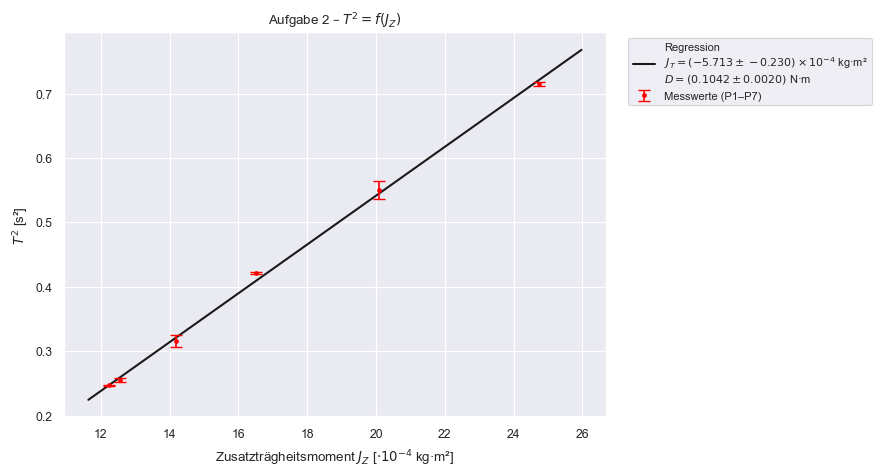

In [7]:
# ── Plot ──────────────────────────────────────────────────────────
J_Z_fit = np.linspace(J_Z.min() * 0.95, J_Z.max() * 1.05, 200)
T2_fit  = model2.params[0] + model2.params[1] * J_Z_fit

fig, ax = plt.subplots(figsize=(7, 5))


ax.plot(
    J_Z_fit * 1e4, T2_fit,
    'k-', lw=1.5,
    label=(
        f'Regression\n'
        f'$J_T = ({J_T*1e4:.3f} \\pm {dJ_T*1e4:.3f})\\times10^{{-4}}$ kg·m²\n'
        f'$D = ({D:.4f} \\pm {dD:.4f})$ N·m'
    )
)
ax.errorbar(
    J_Z * 1e4, T2_pos,
    yerr=dT2_pos,
    fmt='.', color='red', capsize=4,
    label='Messwerte (P1–P7)'
)

ax.set_xlabel(r'Zusatzträgheitsmoment $J_Z$ [$\cdot 10^{-4}$ kg·m²]')
ax.set_ylabel(r'$T^2$ [s²]')
ax.set_title(r'Aufgabe 2 – $T^2 = f(J_Z)$')
ax.legend(
    loc='upper right',
    fontsize='small',
    bbox_to_anchor=(1.5, 1)
)
# plt.tight_layout()
plt.show()

# ── Speichern (copy-paste snippet) ────────────────────────────────
# fig.savefig('M2_Aufgabe2.png', dpi=600, bbox_inches='tight')

### Aufgabe 4 – $J_\gamma = f(\sin^2\gamma)$: Überprüfung des Trägheitsellipsoids

> *Lineare Regression nach Gl. (12): $J_\gamma = J_z + (J_y - J_z)\sin^2\gamma$, mit den Hauptträgheitsmomenten $J_z$ (γ = 0°) und $J_y$ (γ = 90°) als Regressionsergebnisse.*

In [8]:
# ── Periodendauer und J_gamma berechnen ───────────────────────────
T_zyl, dT_zyl = periodendauer(
    df_zylinder['T1_s'].values,
    df_zylinder['T2_s'].values,
    df_zylinder['Schwingungen_n'].values
)
T2_zyl  = T_zyl**2
dT2_zyl = 2 * T_zyl * dT_zyl

J_gamma  = J_aus_T2(T2_zyl, D, J_T)
dJ_gamma = dT2_zyl * D / (4 * np.pi**2)   # Fehlerfortpflanzung

# ── sin²γ ─────────────────────────────────────────────────────────
gamma_rad  = np.deg2rad(df_zylinder['gamma_grad'].values)
sin2_gamma = np.sin(gamma_rad)**2

# ── NaN-Maske: nur gültige Zeilen verwenden ───────────────────────
mask_valid = ~np.isnan(sin2_gamma) & ~np.isnan(J_gamma)
print(f"Entfernte Zeilen: {np.sum(~mask_valid)}")
print(f"Verbleibende Punkte: {np.sum(mask_valid)}")

sin2_gamma_clean = sin2_gamma[mask_valid]
J_gamma_clean    = J_gamma[mask_valid]
dJ_gamma_clean   = dJ_gamma[mask_valid]

# ── Lineare Regression ────────────────────────────────────────────
model4, J_z, dJ_z, J_y, dJ_y = regression_ellipsoid(sin2_gamma_clean, J_gamma_clean)

display(model4.summary())
print(f"\n  J_z (γ=0°)  = ({J_z*1e4:.4f} ± {dJ_z*1e4:.4f}) × 10⁻⁴ kg·m²")
print(f"  J_y (γ=90°) = ({J_y*1e4:.4f} ± {dJ_y*1e4:.4f}) × 10⁻⁴ kg·m²")

Entfernte Zeilen: 1
Verbleibende Punkte: 7


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.992
Model:                            OLS   Adj. R-squared:                  0.991
Method:                 Least Squares   F-statistic:                     633.3
Date:                Tue, 09 Jun 2026   Prob (F-statistic):           1.85e-06
Time:                        14:03:25   Log-Likelihood:                 63.516
No. Observations:                   7   AIC:                            -123.0
Df Residuals:                       5   BIC:                            -123.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0015   2.06e-05     72.511      0.000       0.001       0.002
x1             0.0008   3.28e-05     25.166      0.000       0.001       0.001
==============================================================================
Omnibus:                          nan   Durbin-Watson:                   2.913
Prob(Omnibus):                    nan   Jarque-Bera (JB):                1.061
Skew:                           0.942   Prob(JB):                        0.588
Kurtosis:                       3.302   Cond. No.                         3.39
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""


  J_z (γ=0°)  = (14.9180 ± 0.2057) × 10⁻⁴ kg·m²
  J_y (γ=90°) = (23.1783 ± 0.2057) × 10⁻⁴ kg·m²


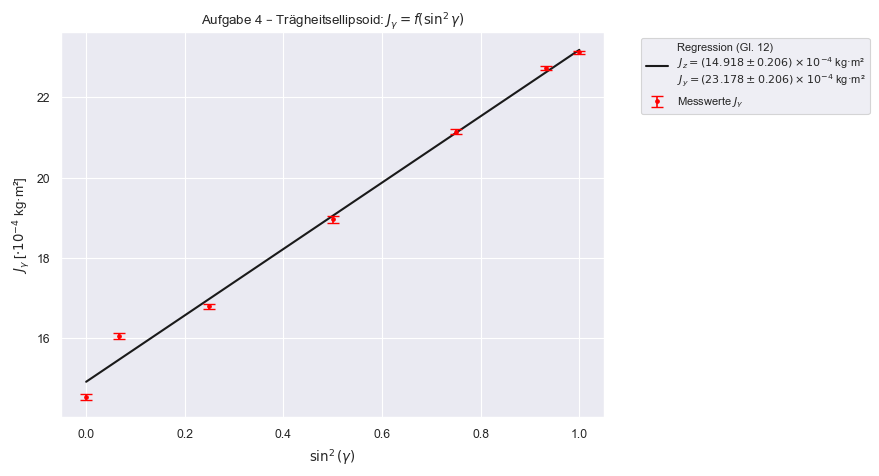

In [9]:
# ── Plot ──────────────────────────────────────────────────────────
sin2_fit = np.linspace(0, 1, 200)
J_fit    = model4.params[0] + model4.params[1] * sin2_fit

fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(
    sin2_fit, J_fit * 1e4,
    'k-', lw=1.5,
    label=(
        f'Regression (Gl. 12)\n'
        f'$J_z = ({J_z*1e4:.3f} \\pm {dJ_z*1e4:.3f})\\times10^{{-4}}$ kg·m²\n'
        f'$J_y = ({J_y*1e4:.3f} \\pm {dJ_y*1e4:.3f})\\times10^{{-4}}$ kg·m²'
    )
)
ax.errorbar(
    sin2_gamma, J_gamma * 1e4,
    yerr=dJ_gamma * 1e4,
    fmt='.', color='red', capsize=4,
    label='Messwerte $J_\\gamma$'
)

ax.set_xlabel(r'$\sin^2(\gamma)$')
ax.set_ylabel(r'$J_\gamma$ [$\cdot10^{-4}$ kg·m²]')
ax.set_title(r'Aufgabe 4 – Trägheitsellipsoid: $J_\gamma = f(\sin^2\gamma)$')
ax.legend(
    loc='upper right',
    fontsize='small',
    bbox_to_anchor=(1.5, 1)
)
# plt.tight_layout()
plt.show()

# ── Speichern (copy-paste snippet) ────────────────────────────────
# fig.savefig('M2_Aufgabe4.png', dpi=600, bbox_inches='tight')

### Aufgabe 5 – Vergleich experimenteller und theoretischer Hauptträgheitsmomente

> *Die experimentellen Werte für $J_{\gamma=0°}$ und $J_{\gamma=90°}$ aus Aufgabe 4 (Regression) werden mit den direkt gemessenen Werten und den theoretischen Werten nach Gl. (13) verglichen.*

In [10]:
# ── Theoretische Werte mit Fehlerfortpflanzung ────────────────────
J_0_theo, J_90_theo, dJ_0_theo, dJ_90_theo = J_theoretisch(
    m_zyl, R_zyl, h_zyl, u_m_zyl, u_R_zyl, u_h_zyl
)

print(f"Theoretische Hauptträgheitsmomente (Gl. 13):")
print(f"  J_0  (γ=0°)  = ({J_0_theo*1e4:.4f} ± {dJ_0_theo*1e4:.4f}) × 10⁻⁴ kg·m²")
print(f"  J_90 (γ=90°) = ({J_90_theo*1e4:.4f} ± {dJ_90_theo*1e4:.4f}) × 10⁻⁴ kg·m²")

# ── Experimentelle Werte direkt aus Aufgabe 3 (γ = 0° und 90°) ───
gamma_vals = df_zylinder['gamma_grad'].values
mask_0     = gamma_vals == 0
mask_90    = gamma_vals == 90

J_exp_0   = J_gamma[mask_0][0]   if mask_0.any()  else np.nan
dJ_exp_0  = dJ_gamma[mask_0][0]  if mask_0.any()  else np.nan
J_exp_90  = J_gamma[mask_90][0]  if mask_90.any() else np.nan
dJ_exp_90 = dJ_gamma[mask_90][0] if mask_90.any() else np.nan

# ── Vergleichstabelle ─────────────────────────────────────────────
df_vergleich = pd.DataFrame({
    'Größe': ['$J_z$ (γ=0°)', '$J_y$ (γ=90°)'],
    'Exp. direkt [×10⁻⁴ kg·m²]': [
        f"{J_exp_0*1e4:.4f} ± {dJ_exp_0*1e4:.4f}",
        f"{J_exp_90*1e4:.4f} ± {dJ_exp_90*1e4:.4f}"
    ],
    'Exp. Regression [×10⁻⁴ kg·m²]': [
        f"{J_z*1e4:.4f} ± {dJ_z*1e4:.4f}",
        f"{J_y*1e4:.4f} ± {dJ_y*1e4:.4f}"
    ],
    'Theorie Gl.(13) [×10⁻⁴ kg·m²]': [
        f"{J_0_theo*1e4:.4f} ± {dJ_0_theo*1e4:.4f}",
        f"{J_90_theo*1e4:.4f} ± {dJ_90_theo*1e4:.4f}"
    ],
})

print("\n=== Vergleich der Hauptträgheitsmomente ===")
display(df_vergleich)

Theoretische Hauptträgheitsmomente (Gl. 13):
  J_0  (γ=0°)  = (3.2867 ± 0.0745) × 10⁻⁴ kg·m²
  J_90 (γ=90°) = (13.1365 ± 0.1197) × 10⁻⁴ kg·m²

=== Vergleich der Hauptträgheitsmomente ===


,Größe,Exp. direkt [×10⁻⁴ kg·m²],Exp. Regression [×10⁻⁴ kg·m²],Theorie Gl.(13) [×10⁻⁴ kg·m²]
0,$J_z$ (γ=0°),14.5452 ± 0.0763,14.9180 ± 0.2057,3.2867 ± 0.0745
1,$J_y$ (γ=90°),23.1137 ± 0.0429,23.1783 ± 0.2057,13.1365 ± 0.1197


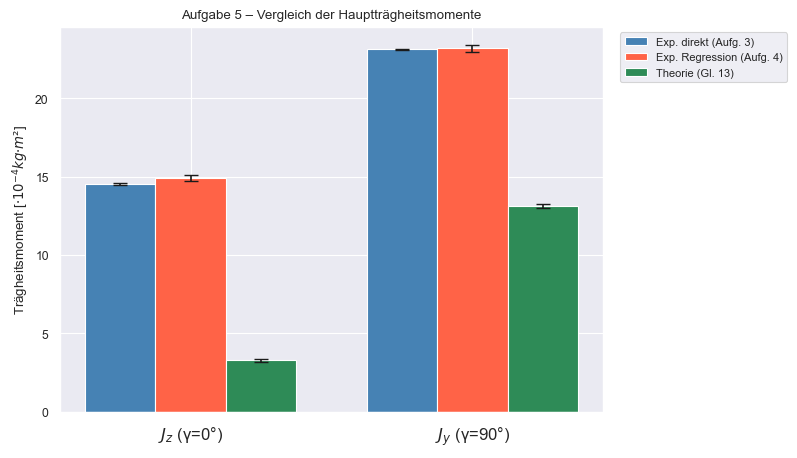

In [12]:
# ── Plot ──────────────────────────────────────────────────────────
labels  = ['$J_z$ (γ=0°)', '$J_y$ (γ=90°)']
J_exp3  = np.array([J_exp_0,    J_exp_90])    * 1e4
dJ_exp3 = np.array([dJ_exp_0,   dJ_exp_90])   * 1e4
J_reg   = np.array([J_z,        J_y])          * 1e4
dJ_reg  = np.array([dJ_z,       dJ_y])         * 1e4
J_theo  = np.array([J_0_theo,   J_90_theo])    * 1e4
dJ_theo = np.array([dJ_0_theo,  dJ_90_theo])   * 1e4

x = np.arange(len(labels))
w = 0.25

fig, ax = plt.subplots(figsize=(7, 5))

ax.bar(x - w, J_exp3,  w, yerr=dJ_exp3,  capsize=5,
       color='steelblue', label='Exp. direkt (Aufg. 3)')
ax.bar(x,     J_reg,   w, yerr=dJ_reg,   capsize=5,
       color='tomato',   label='Exp. Regression (Aufg. 4)')
ax.bar(x + w, J_theo,  w, yerr=dJ_theo,  capsize=5,
       color='seagreen', label='Theorie (Gl. 13)')

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=12)
ax.set_ylabel(r'Trägheitsmoment [$\cdot10^{-4} kg·m²$]')
ax.set_title('Aufgabe 5 – Vergleich der Hauptträgheitsmomente')
ax.legend(
    loc='upper right',
    fontsize='small',
    bbox_to_anchor=(1.35, 1)
)
# plt.tight_layout()
plt.show()

# ── Speichern (copy-paste snippet) ────────────────────────────────
# fig.savefig('M2_Aufgabe5.png', dpi=600, bbox_inches='tight')